# Разведочный анализ данных: начало

Мы будем работать с датасетом про алмазы - в нем содержатся их различные характеристики, а также стоимость.

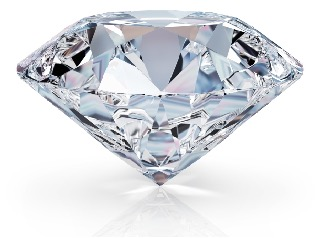

[Интересная статья про качество алмазов](https://www.diamonds.pro/education/diamond-depth-and-table/)

**Цели на сегодня:**

* понять влияние различных характеристик алмазов на их качество и стоимость

* научиться делать разведочный анализ данных

* изучить библиотеки pandas, numpy и matplotlib, seaborn

[Pandas cheatsheet](https://images.datacamp.com/image/upload/v1676302204/Marketing/Blog/Pandas_Cheat_Sheet.pdf)

## Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DIAMONDS_DATASET = "/content/drive/MyDrive/data/eda/diamonds_good.csv"

In [4]:
df = pl.read_csv(DIAMONDS_DATASET)

## Описание данных

* `carat` - число каратов алмаза
* `cut` - огранка алмаза
* `color` - цвет алмаза
* `clarity` - прозрачность алмаза
* `depth` - глубина алмаза
* `table` - платформа алмаза (грань, которую можно увидеть, если смотреть на камень лицевой стороной вверх)
* `price` - цена алмаза
* `x` - размер алмаза по оси x
* `y` - размер алмаза по оси y
* `z` - размер алмаза по оси z

In [5]:
df.head(10)

carat,cut,color,clarity,depth,table,price,'x','y','z'
f64,str,str,str,f64,f64,f64,f64,f64,f64
0.23,"""Ideal""","""E""","""SI2""",61.5,55.0,326.0,3.95,3.98,2.43
0.21,"""Premium""","""E""","""SI1""",59.8,61.0,326.0,3.89,3.84,2.31
0.23,"""Good""","""E""","""VS1""",56.9,65.0,327.0,4.05,4.07,2.31
0.29,"""Premium""","""I""","""VS2""",62.4,58.0,334.0,4.2,4.23,2.63
0.31,"""Good""","""J""","""SI2""",63.3,58.0,335.0,4.34,4.35,2.75
null,"""Very Good""","""J""","""VVS2""",62.8,57.0,336.0,3.94,3.96,2.48
0.24,"""Very Good""","""I""","""VVS1""",62.3,57.0,336.0,3.95,3.98,2.47
0.26,"""Very Good""","""H""","""SI1""",61.9,55.0,337.0,4.07,4.11,2.53
0.22,"""Fair""","""E""","""VS2""",65.1,61.0,337.0,3.87,3.78,2.49


In [6]:
df.tail()

carat,cut,color,clarity,depth,table,price,'x','y','z'
f64,str,str,str,f64,f64,f64,f64,f64,f64
0.72,"""Ideal""","""D""","""SI1""",60.8,57.0,2757.0,5.75,5.76,3.5
0.72,"""Good""","""D""","""SI1""",63.1,55.0,2757.0,5.69,5.75,3.61
0.7,"""Very Good""","""D""","""SI1""",62.8,60.0,2757.0,5.66,5.68,3.56
0.86,"""Premium""","""H""","""SI2""",61.0,58.0,2757.0,6.15,6.12,3.74
0.75,"""Ideal""","""D""","""SI2""",62.2,55.0,2757.0,5.83,5.87,3.64


In [7]:
df.sample(3)

carat,cut,color,clarity,depth,table,price,'x','y','z'
f64,str,str,str,f64,f64,f64,f64,f64,f64
1.49,"""Good""","""I""","""SI2""",64.3,59.0,5407.0,7.2,7.1,4.6
1.04,"""Premium""","""I""","""SI2""",61.6,56.0,3960.0,6.56,6.49,4.02
1.51,"""Very Good""","""H""","""VS2""",60.9,57.0,11068.0,7.39,7.43,4.51


## Исследование данных

Размер датасета

In [8]:
df.shape

(53940, 10)

Информация о типах данных и пропусках

In [10]:
df.schema

Schema([('carat', Float64),
        ('cut', String),
        ('color', String),
        ('clarity', String),
        ('depth', Float64),
        ('table', Float64),
        ('price', Float64),
        ("'x'", Float64),
        ("'y'", Float64),
        ("'z'", Float64)])

Основные числовые характеристики

In [11]:
df.describe()

statistic,carat,cut,color,clarity,depth,table,price,'x','y','z'
str,f64,str,str,str,f64,f64,f64,f64,f64,f64
"""count""",53442.0,"""53940""","""53940""","""53940""",52950.0,53940.0,53940.0,53940.0,53935.0,53940.0
"""null_count""",498.0,"""0""","""0""","""0""",990.0,0.0,0.0,0.0,5.0,0.0
"""mean""",0.797561,null,null,null,61.749422,57.457184,3932.799722,5.731157,5.734469,3.538734
"""std""",0.473534,null,null,null,1.431558,2.234491,3989.439738,1.121761,1.142125,0.705699
"""min""",0.2,"""Fair""","""D""","""I1""",43.0,43.0,326.0,0.0,0.0,0.0
"""25%""",0.4,null,null,null,61.0,56.0,950.0,4.71,4.72,2.91
"""50%""",0.7,null,null,null,61.8,57.0,2401.0,5.7,5.71,3.53
"""75%""",1.04,null,null,null,62.5,59.0,5324.0,6.54,6.54,4.04
"""max""",5.01,"""Very Good""","""J""","""VVS2""",79.0,95.0,18823.0,10.74,58.9,31.8


In [15]:
df.is_duplicated().sum()

267

In [ ]:
# df[условие фильтрации]

In [17]:
df.filter(df.is_duplicated())

carat,cut,color,clarity,depth,table,price,'x','y','z'
f64,str,str,str,f64,f64,f64,f64,f64,f64
0.79,"""Ideal""","""G""","""SI1""",62.3,57.0,2898.0,5.9,5.85,3.66
0.79,"""Ideal""","""G""","""SI1""",62.3,57.0,2898.0,5.9,5.85,3.66
0.79,"""Ideal""","""G""","""SI1""",62.3,57.0,2898.0,5.9,5.85,3.66
0.79,"""Ideal""","""G""","""SI1""",62.3,57.0,2898.0,5.9,5.85,3.66
0.79,"""Ideal""","""G""","""SI1""",62.3,57.0,2898.0,5.9,5.85,3.66
…,…,…,…,…,…,…,…,…,…
0.71,"""Good""","""F""","""SI2""",64.1,60.0,2130.0,0.0,0.0,0.0
0.51,"""Ideal""","""F""","""VVS2""",61.2,56.0,2203.0,5.19,5.17,3.17
0.51,"""Ideal""","""F""","""VVS2""",61.2,56.0,2203.0,5.19,5.17,3.17


In [20]:
df = df.unique()

df.shape

(53805, 10)

In [21]:
df.head()

carat,cut,color,clarity,depth,table,price,'x','y','z'
f64,str,str,str,f64,f64,f64,f64,f64,f64
0.33,"""Ideal""","""E""","""VS2""",61.6,55.0,873.0,4.46,4.5,2.76
0.7,"""Very Good""","""E""","""SI1""",61.2,57.0,2753.0,5.68,5.73,3.49
0.38,"""Ideal""","""F""","""I1""",62.5,57.0,638.0,4.64,4.61,2.89
0.7,"""Premium""","""F""","""VS2""",62.2,59.0,2648.0,5.68,5.64,3.52
1.51,"""Very Good""","""H""","""VS2""",63.2,57.0,10950.0,7.18,7.32,4.58


## Работа с пропущенными значениями

Стратегии заполнения пропусков:

* если пропусков очень мало (~меньше процента) - строки с пропусками можно удалить или заполнить средним/медианой

* если пропусков мало (~5-10%) - их можно заполнить (средним, медианой, уникальным значением, самым популярным значением, спрогнозировать)

* если пропусков много - можно удалить столбец

* можно пытаться предсказывать пропуски моделью

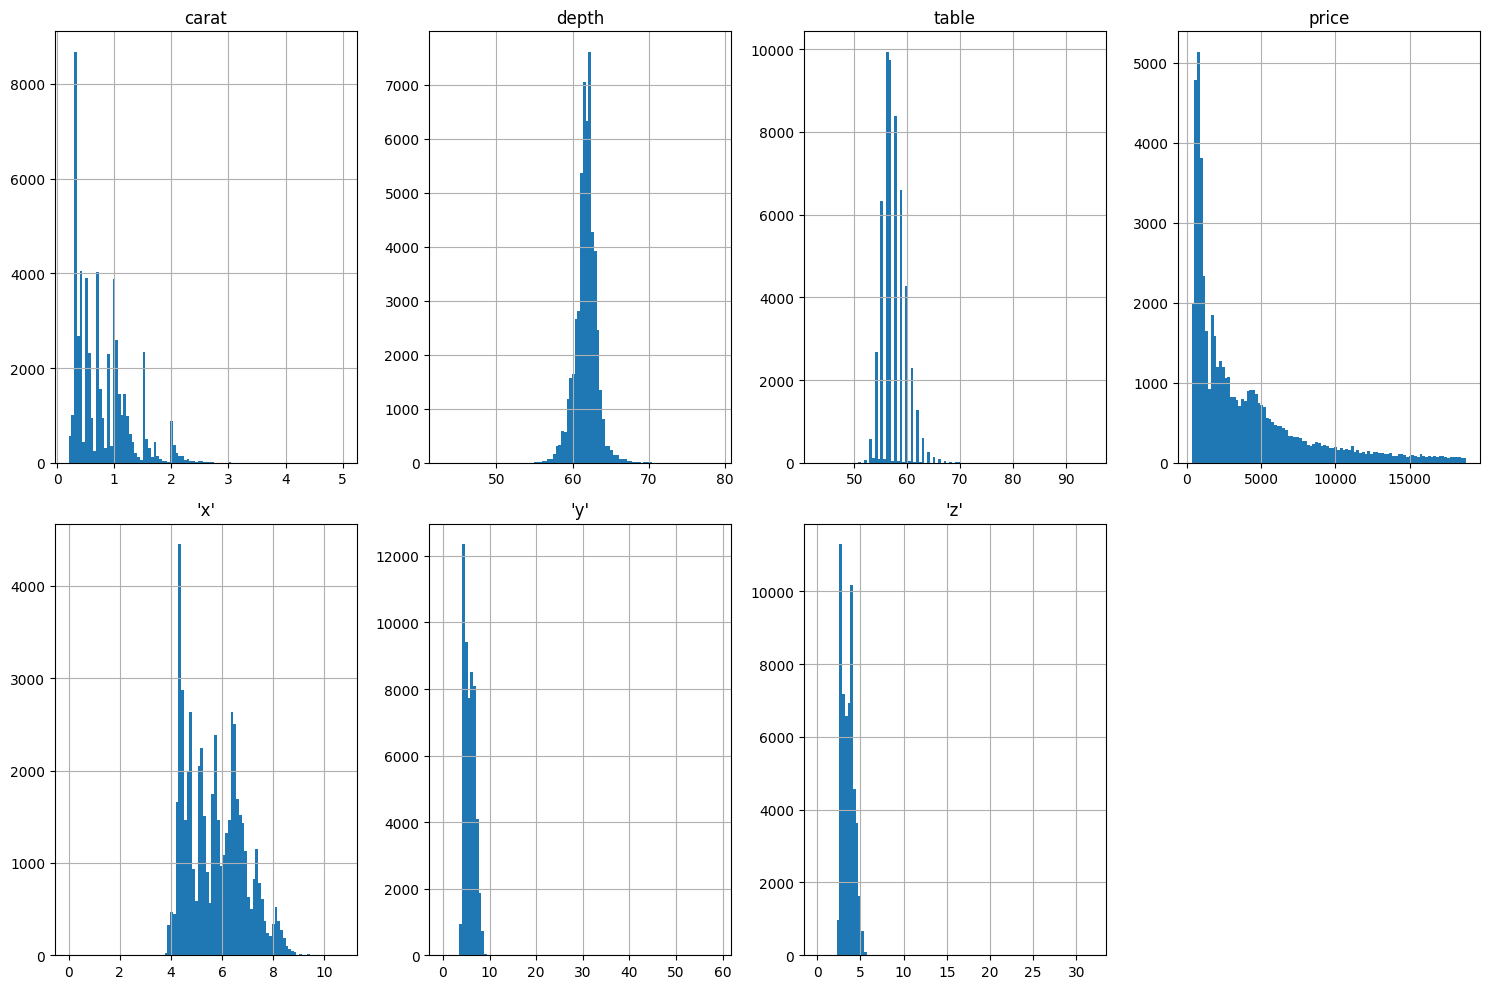

In [30]:
cols = ["carat","depth","table","price","'x'","'y'","'z'"]

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(cols):
    axes[idx].hist(df[col].to_numpy(), bins=100)
    axes[idx].set_title(col)
    axes[idx].grid()

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
median_carat = round(df['carat'].median(), 2)

df = df.with_columns(
    pl.col('carat').fill_null(median_carat)
)

In [32]:
median_depth = round(df['depth'].median(), 2)
df = df.with_columns(
    pl.col('depth').fill_null(median_depth)
)


### Задание 1

Заполните пропуски в столбце `y` медианным значением. Чему равно это значение? Ответ округлите до сотых.

In [33]:
median_y = round(df['\'y\''].median(), 2)
print('Мединное значение y: ' + str(median_y))

Мединное значение y: 5.71


In [34]:
df = df.with_columns(
    pl.col('\'y\'').fill_null(median_depth)
)

## Однофакторный анализ

### Число карат

* мелкие — массой до 0,30 карат (не включительно);
* средние — массой от 0,30 до 1 карат (не включительно);
* крупные – 1 карат и выше, называют солитеры.


Небольшие бриллианты различного размера, полученные при огранке алмаза, и весящие каждый в отдельности менее 0,25 карат, называют *melee (мили)*. Полученные таким же путем более крупные бриллианты различного размера называют *melange (меланж)*.


Бриллианты более 6 карат обычно продаются c аукционов.


Алмазам и бриллиантам более 25 карат присваивают собственные имена.

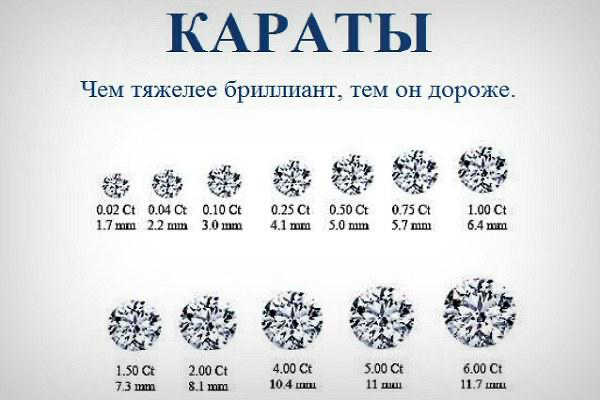

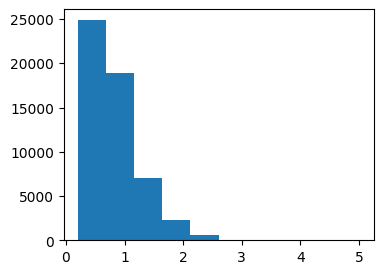

In [45]:
plt.figure(figsize=(4,3))

plt.hist(df['carat']);

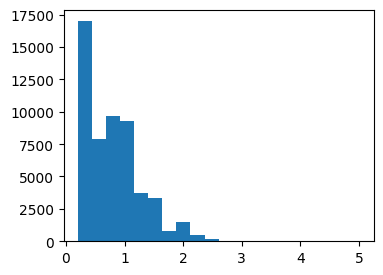

In [46]:
plt.figure(figsize=(4,3))

plt.hist(df['carat'], bins=20);

Сколько карат весит самый тяжелый бриллиант в датасете? А самый легкий?

In [40]:
df['carat'].min(), df['carat'].max()

(0.2, 5.01)

Сколько мелких бриллиантов в датасете?

In [42]:
len(df.filter(pl.col('carat') < 0.3))

1582

Сколько процентов бриллиантов среди всего датасета - крупные?

In [44]:
round(100 * len(df.filter(pl.col('carat') >= 1)) / len(df))

35

Посмотрим как число карат влияет на стоимость алмаза

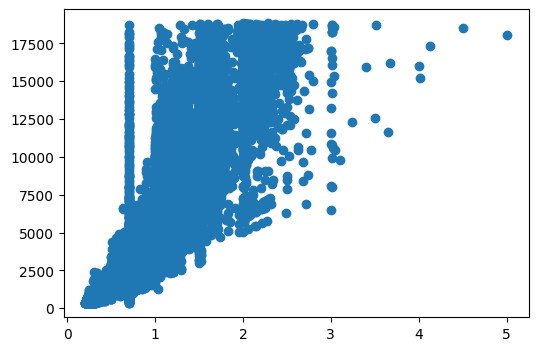

In [47]:
plt.figure(figsize=(6,4))

plt.scatter(df['carat'], df['price']);

In [48]:
np.corrcoef(df['carat'], df['price'])[0][1]

np.float64(0.9164989435440217)

### Cut (огранка алмаза)

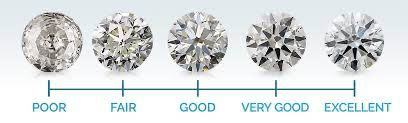

In [49]:
df['cut'].value_counts(normalize=True)

cut,proportion
str,f64
"""Premium""",0.255088
"""Very Good""",0.224013
"""Good""",0.090772
"""Ideal""",0.398941
"""Fair""",0.0297
"""Goood""",0.001487


In [50]:
df = df.with_columns(
    pl.col('cut').replace({'Goood': 'Good'})
)

Посмотрим как влияет огранка алмаза на его стоимость

/tmp/ipython-input-1625806102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cut', y='price', data = df, palette='summer')


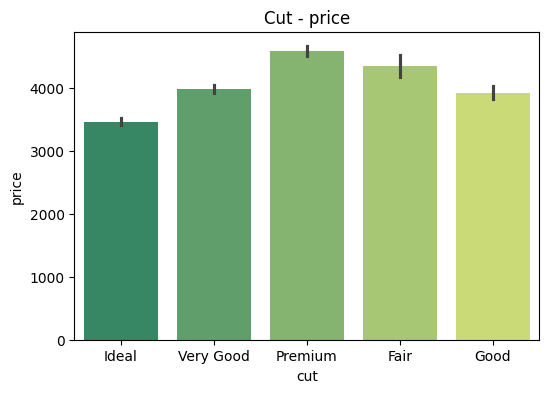

In [51]:
plt.figure(figsize=(6,4))

sns.barplot(x='cut', y='price', data = df, palette='summer')
plt.title('Cut - price')
plt.show();

### Задание 2

Какое максимальное число карат весит алмаз огранки `Fair`?
Ответ округлите до сотых.

In [53]:
# ваш код здесь
df.filter(pl.col('cut') == 'Fair').select(pl.col('carat')).max()

carat
f64
5.01


Посчитаем среднюю стоимость алмазов в каждой категории

In [55]:
df.group_by('cut').agg(pl.col('price').mean())

cut,price
str,f64
"""Premium""",4581.864918
"""Very Good""",3982.162781
"""Fair""",4347.735294
"""Good""",3926.266317
"""Ideal""",3462.59385


Посчитаем несколько характеристик в зависимости от огранки

In [57]:
df.group_by('cut').agg(
    pl.col('price').mean().alias('PriceMean'),
    pl.col('price').median().alias('PriceMedian'),
    pl.col('carat').mean().alias('CaratMean')
)

cut,PriceMean,PriceMedian,CaratMean
str,f64,f64,f64
"""Fair""",4347.735294,3282.0,1.040094
"""Premium""",4581.864918,3175.0,0.889616
"""Very Good""",3982.162781,2649.0,0.804177
"""Ideal""",3462.59385,1813.0,0.703331
"""Good""",3926.266317,3029.5,0.845796


In [59]:
df.group_by('cut').agg(
    pl.col('price').mean().alias('PriceMean'),
    pl.col('price').median().alias('PriceMedian'),
    pl.col('carat').mean().alias('CaratMean')
).sort('PriceMean', descending=False)

cut,PriceMean,PriceMedian,CaratMean
str,f64,f64,f64
"""Ideal""",3462.59385,1813.0,0.703331
"""Good""",3926.266317,3029.5,0.845796
"""Very Good""",3982.162781,2649.0,0.804177
"""Fair""",4347.735294,3282.0,1.040094
"""Premium""",4581.864918,3175.0,0.889616


## Table and Depth

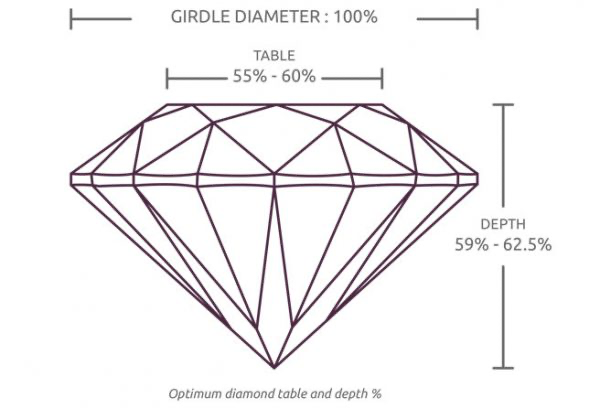

Оптимальное значение параметра `table` для алмаза [55%; 60%].

Какая доля алмазов в данных имеют оптимальное значение `table`?

In [60]:
len(df.filter((pl.col('table') >= 55) & (pl.col('table') <= 60))) / len(df)

0.8439364371340954

### Задание 3

Оптимальное значение параметра `depth` для алмаза [59%; 62.5%].

Какая доля алмазов в данных имеют одновременно оптимальное значение `table` и `depth`?

Ответ округлите до сотых.

In [61]:
# ваш код здесь
optimal_df = df.filter((pl.col('table') >= 55) & (pl.col('table') <= 60) & (pl.col('depth') >= 59) & (pl.col('depth') <= 62.5))
round(len(optimal_df) / len(df), 2)

0.62

### Задание 4

Сравните медианную стоимость всех алмазов, и алмазов с оптимальными table & depth. Какая больше?

In [63]:
# ваш код здесь
print('Медианная стоимость всех алмазов: ' + str(df['price'].median()))
print('Медианная стоимость оптимальных алмазов: ' + str(optimal_df['price'].median()))

Медианная стоимость всех алмазов: 2401.0
Медианная стоимость оптимальных алмазов: 2215.0


Вычислите корреляцию `table` и `price`, а затем `depth`и `price`. Какой параметр влияет на цену больше?

In [65]:
np.corrcoef(df['table'], df['price'])[0][1]

np.float64(0.12662153885758187)

In [66]:
np.corrcoef(df['depth'], df['price'])[0][1]

np.float64(-0.010831614226837231)

## Clarity - прозрачность алмаза

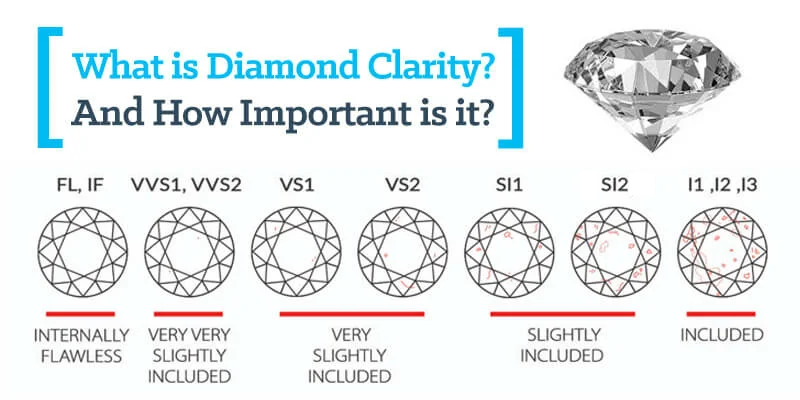

### Задание 5

Сколько различных градаций есть в столбце `clarity`?

In [67]:
# ваш код здесь
df['clarity'].unique()

clarity
str
"""VS1"""
"""VVS1"""
"""SI1"""
"""VS2"""
"""I1"""
"""IF"""
"""VVS2"""
"""SI2"""


### Задание 6

Сколько алмазов в таблице, относящихся к категории `very very slightly included`?

In [69]:
# ваш код здесь
len(df.filter((df['clarity'] == "VVS1") | (df['clarity'] == "VVS2")))

8704

### Задание 7

Нарисуйте график зависимости цены алмазов от `clarity`. Алмазы какой категории в наших данных стоят дороже остальных?

/tmp/ipython-input-62671584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='clarity', y='price', data = df, palette='summer')


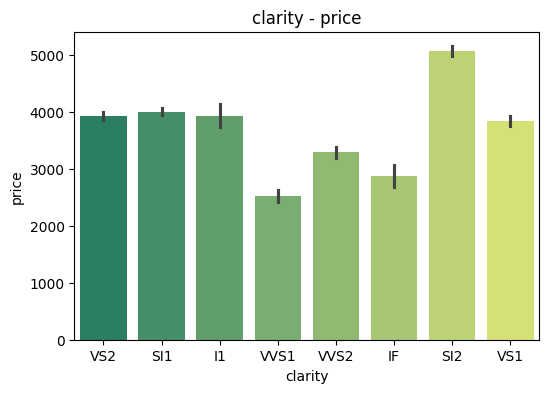

In [70]:
# ваш код здесь
plt.figure(figsize=(6,4))

sns.barplot(x='clarity', y='price', data = df, palette='summer')
plt.title('clarity - price')
plt.show()

### Задание 8

Для каждой пары значений категорий (`cut`,`clarity`) вычислим среднюю и медианную стоимость. Результат отсортируем по убыванию средней стоимости.

Алмазы какой огранки (`cut`) в совокупностью с некоторой категорией `clarity` имеют наибольшую среднюю стоимость?

In [72]:
# ваш код здесь
df.group_by(['cut', 'clarity']).agg(
    PriceMean=pl.col('price').mean(),
    PriceMedian=pl.col('price').median()
).sort('PriceMean', descending=True)

cut,clarity,PriceMean,PriceMedian
str,str,f64,f64
"""Premium""","""SI2""",5556.262491,4292.5
"""Fair""","""SI2""",5145.740175,3681.0
"""Very Good""","""SI2""",4988.709447,4042.0
"""Ideal""","""SI2""",4761.711917,4068.0
"""Good""","""SI2""",4544.119816,3763.0
…,…,…,…
"""Ideal""","""VVS1""",2474.09024,1114.0
"""Very Good""","""VVS1""",2451.883249,941.0
"""Ideal""","""IF""",2279.618257,1020.0


## Pandas profiling

In [ ]:
# !pip install ydata_profiling
!pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip -q

     | 17.9 MB 23.0 MB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
df_copy = pd.read_csv(DIAMONDS_DATASET)

profile_report = ProfileReport(df_copy, title='Pandas Profiling Report')

In [ ]:
profile_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 10.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile_report.to_file('Diamonds_report.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Домашнее задание

## 1) x, y, z

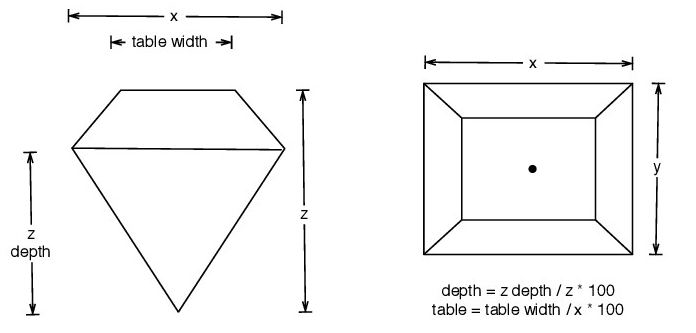

In [73]:
df.columns

['carat',
 'cut',
 'color',
 'clarity',
 'depth',
 'table',
 'price',
 "'x'",
 "'y'",
 "'z'"]

Переименуем колонки

In [75]:
df = df.rename({
    "'x'": 'x',
    "'y'": 'y',
    "'z'": 'z'
})

df.columns

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

### Задание 1

Для каждого из трех столбцов (`x`, `y`, `z`) вычислите медианное значение. В ответ запишите максимальное из полученных чисел без округлений.

In [76]:
# ваш код здесь
max(df['x'].median(), df['y'].median(), df['z'].median())

5.71

Для каждого из этих столбцов вычислите минимальное значение.

In [78]:
df['x'].min(), df['y'].min(), df['z'].min()

(0.0, 0.0, 0.0)

Нулевые размеры - явно ошибки.

### Задание 2

Выведите на экран все строки таблицы (только столбцы `x`,`y`,`z`), в которых хотя бы одна из координат равна нулю.

Сколько таких строк?

In [80]:
# ваш код здесь
df.filter((df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0))

carat,cut,color,clarity,depth,table,price,x,y,z
f64,str,str,str,f64,f64,f64,f64,f64,f64
1.0,"""Very Good""","""H""","""VS2""",63.3,53.0,5139.0,0.0,0.0,0.0
1.5,"""Good""","""G""","""I1""",64.0,61.0,4731.0,7.15,7.04,0.0
0.71,"""Good""","""F""","""SI2""",64.1,60.0,2130.0,0.0,0.0,0.0
1.1,"""Premium""","""G""","""SI2""",63.0,59.0,3696.0,6.5,6.47,0.0
1.01,"""Premium""","""F""","""SI2""",59.2,58.0,3837.0,6.5,6.47,0.0
…,…,…,…,…,…,…,…,…,…
2.8,"""Good""","""G""","""SI2""",63.8,58.0,18788.0,8.9,8.85,0.0
1.2,"""Premium""","""D""","""VVS1""",62.1,59.0,15686.0,0.0,0.0,0.0
2.25,"""Premium""","""H""","""SI2""",62.8,59.0,18034.0,0.0,0.0,0.0


In [83]:
print('Количество строк: ' + str(len(df.filter((df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)))))

Количество строк: 19


### Задание 3

Удалите из таблицы эти строки. Сколько строк осталось в таблице?

In [86]:
# ваш код здесь
df = df.filter((pl.col('x') != 0) & (pl.col('y') != 0) & (pl.col('z') != 0))

In [87]:
print('Осталось строк: ' + str(len(df)))

Осталось строк: 53786


### Задание 4

Вычислите корреляцию между каждым из этих столбцов и `price`. Какой столбец коррелирует с ценой алмаза больше всего?

In [89]:
# ваш код здесь
x_price_core = round(np.corrcoef(df['price'], df['x'])[0][1], 4)
x_price_core

np.float64(0.8872)

In [90]:
y_price_core = round(np.corrcoef(df['price'], df['y'])[0][1], 4)
y_price_core

np.float64(0.7862)

In [91]:
z_price_core = round(np.corrcoef(df['price'], df['z'])[0][1], 4)
z_price_core

np.float64(0.8681)

Больше всего коррелирует столбец x

### Задание 5

Постройте scatter-plot для отражения зависимости между ценой алмаза и координатой, наиболее с ней коррелирующей. На какую зависимость она больше всего похожа?

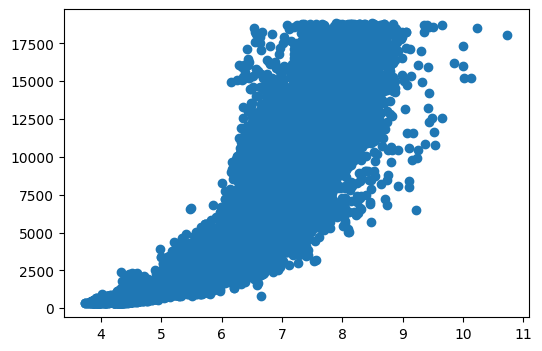

In [92]:
# ваш код здесь
plt.figure(figsize=(6,4))

plt.scatter(df['x'], df['price'])

### Задание 6

Какой процент среди всех алмазов имеет `x` и `y` размеры, превышающие средние значения (по `x` и `y`)? Ответ округлите до целого числа.

In [94]:
# ваш код здесь
x_mean = df['x'].mean()
y_mean = df['y'].mean()

round(len(df.filter((df['x'] > x_mean) & (df['y'] > y_mean))) / len(df) * 100)

47

### Задание 7

Какая доля среди крупных алмазов имеет `z`-размеры, меньшие медианного? Ответ округлите до четырех знаков после запятой.

In [98]:
# ваш код здесь
z_median = df['z'].median()
round(len(df.filter((df['z'] < z_median) & (df['carat'] >= 1))) / len(df) * 100, 4)

0.0074

## 2) Color

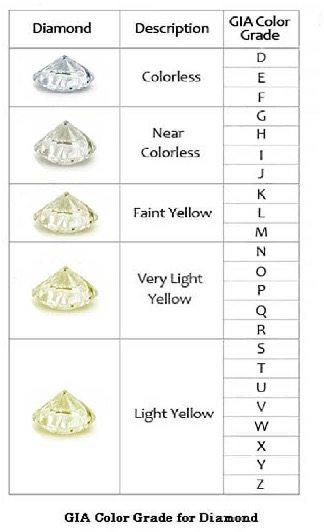

### Задание 8

К каким категориям (Description) из градации выше относятся алмазы в данных?

In [99]:
# ваш код здесь
def get_description(color):
  match color:
    case 'D' | 'E' | 'F':
        return 'Colorless'
    case 'G' | 'H' | 'I' | 'J':
        return 'Near Colorless'
    case 'K' | 'L' | 'M':
        return 'Faint Yellow'
    case 'N' | 'O' | 'P' | 'Q' | 'R':
        return 'Very Light Yellow'
    case _:
        return 'Light Yellow'

In [102]:
df = df.clone()
df = df.with_columns(
    pl.col('color')
    .map_elements(get_description, return_dtype=pl.Utf8)
    .alias('description')
)

In [103]:
df['description'].unique()

description
str
"""Colorless"""
"""Near Colorless"""


### Задание 9

Нарисуйте график, отражающий зависимость стоимости алмазов от его категории цвета.

Алмазы какого цвета стоят дороже остальных?

/tmp/ipython-input-1741877154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='description', y='price', data = df, palette='summer')


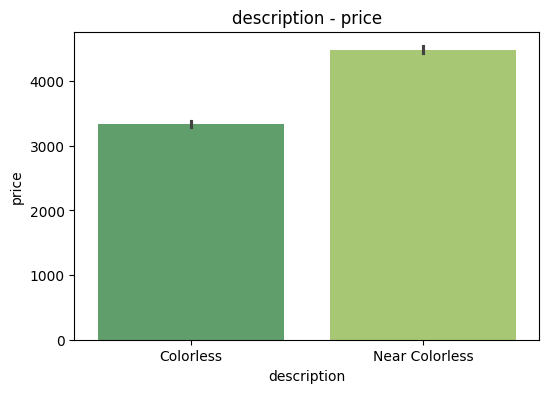

In [104]:
# ваш код здесь
plt.figure(figsize=(6,4))

sns.barplot(x='description', y='price', data = df, palette='summer')
plt.title('description - price')
plt.show()

### Задание 10

Для каждого цвета алмаза вычислите медианную стоимость и медианный вес (в каратах). Отсортируйте полученную при помощи groupby таблицу по убыванию медианной стоимости.

Верно ли, что при убывании PriceMedian, сгруппированной по цвету, CaratMedian также убывает? (не возрастает)

In [105]:
# ваш код здесь
df.group_by('color').agg(
    pl.col('price').median().alias('PriceMedian'),
    pl.col('carat').median().alias('CaratMedian')
).sort('PriceMedian', descending=True)

color,PriceMedian,CaratMedian
str,f64,f64
"""J""",4234.5,1.11
"""I""",3721.5,1.0
"""H""",3449.5,0.9
"""F""",2345.0,0.7
"""G""",2242.0,0.7
"""D""",1842.0,0.54
"""E""",1741.0,0.54


### Задание 11

Вычислите среднюю стоимость алмазов по каждой тройке категорий (`cut`,`color`,`clarity`). Какие алмазы дороже остальных?

В ответе запишите тройку названий в скобках через запятую, без кавычек и пробелов. Например, (Premium,D,IF)

In [109]:
# ваш код здесь
res = df.group_by(['cut', 'color', 'clarity']).agg(
    pl.col('price').mean().alias('PriceMean')
).sort('PriceMean', descending=True).head(3)

In [114]:
for row in res.iter_rows():
  cut, color, clarity, price_mean = row
  print(f"({cut}, {color}, {clarity})")

(Very Good, D, IF)
(Good, D, IF)
(Ideal, J, I1)


# Data Encoding


In [116]:
df_encoded = df.clone()

In [117]:
df.schema

Schema([('carat', Float64),
        ('cut', String),
        ('color', String),
        ('clarity', String),
        ('depth', Float64),
        ('table', Float64),
        ('price', Float64),
        ('x', Float64),
        ('y', Float64),
        ('z', Float64),
        ('description', String)])

### Уникальные значения color

In [122]:
print(df_encoded["color"].unique())

shape: (7,)
Series: 'color' [str]
[
	"H"
	"I"
	"J"
	"D"
	"E"
	"G"
	"F"
]


### Уникальные значения cut

In [123]:
print(df_encoded["cut"].unique())

shape: (5,)
Series: 'cut' [str]
[
	"Ideal"
	"Premium"
	"Fair"
	"Very Good"
	"Good"
]


### Уникальные значения clarity

In [124]:
print(df_encoded["clarity"].unique())

shape: (8,)
Series: 'clarity' [str]
[
	"VS1"
	"SI1"
	"SI2"
	"I1"
	"IF"
	"VVS2"
	"VVS1"
	"VS2"
]


### Кодирование Cut

In [135]:
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
df_encoded = df_encoded.with_columns(
    pl.col('cut')
    .map_elements(lambda x: cut_order[x])
    .alias('cut_encoded')
)

df_encoded = df_encoded.drop(['cut'])

/tmp/ipython-input-771981519.py:4: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("cut").map_elements(lambda x: ...)
with this one instead:
  + pl.col("cut").replace_strict(cut_order)

  .map_elements(lambda x: cut_order[x])
/tmp/ipython-input-771981519.py:2: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df_encoded = df_encoded.with_columns(


In [136]:
df_encoded.head(5)

carat,color,clarity,depth,table,price,x,y,z,description,cut_encoded
f64,str,str,f64,f64,f64,f64,f64,f64,str,i64
0.33,"""E""","""VS2""",61.6,55.0,873.0,4.46,4.5,2.76,"""Colorless""",4
0.7,"""E""","""SI1""",61.2,57.0,2753.0,5.68,5.73,3.49,"""Colorless""",2
0.38,"""F""","""I1""",62.5,57.0,638.0,4.64,4.61,2.89,"""Colorless""",4
0.7,"""F""","""VS2""",62.2,59.0,2648.0,5.68,5.64,3.52,"""Colorless""",3
1.51,"""H""","""VS2""",63.2,57.0,10950.0,7.18,7.32,4.58,"""Near Colorless""",2


In [138]:
print(df_encoded["cut_encoded"].unique())

shape: (5,)
Series: 'cut_encoded' [i64]
[
	0
	1
	2
	3
	4
]


### Кодирование clarity

In [141]:
clarity_order = {'IF': 1, 'VVS2': 2, 'VVS1': 2, 'VS1': 3, 'VS2': 4, 'SI1': 5, 'SI2': 6, 'I1': 7}
df_encoded = df_encoded.with_columns(
    pl.col('clarity')
    .map_elements(lambda x: clarity_order[x])
    .alias('clarity_encoded')
)

df_encoded = df_encoded.drop(['clarity'])

/tmp/ipython-input-249666684.py:4: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("clarity").map_elements(lambda x: ...)
with this one instead:
  + pl.col("clarity").replace_strict(clarity_order)

  .map_elements(lambda x: clarity_order[x])
/tmp/ipython-input-249666684.py:2: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df_encoded = df_encoded.with_columns(


In [142]:
df_encoded.head(5)

carat,color,depth,table,price,x,y,z,description,cut_encoded,clarity_encoded
f64,str,f64,f64,f64,f64,f64,f64,str,i64,i64
0.33,"""E""",61.6,55.0,873.0,4.46,4.5,2.76,"""Colorless""",4,4
0.7,"""E""",61.2,57.0,2753.0,5.68,5.73,3.49,"""Colorless""",2,5
0.38,"""F""",62.5,57.0,638.0,4.64,4.61,2.89,"""Colorless""",4,7
0.7,"""F""",62.2,59.0,2648.0,5.68,5.64,3.52,"""Colorless""",3,4
1.51,"""H""",63.2,57.0,10950.0,7.18,7.32,4.58,"""Near Colorless""",2,4


In [143]:
print(df_encoded["clarity_encoded"].unique())

shape: (7,)
Series: 'clarity_encoded' [i64]
[
	1
	2
	3
	4
	5
	6
	7
]


### Кодирование color

In [144]:
from sklearn.preprocessing import OneHotEncoder

In [145]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
color_encoded = ohe.fit_transform(df_encoded[['color']])

In [146]:
one_hot_df = pl.DataFrame(
    color_encoded,
    schema=[f'color_{cat}' for cat in ohe.categories_[0]]
)

df_encoded = pl.concat([
    df_encoded.drop('color'),
    one_hot_df
], how='horizontal')

In [147]:
df_encoded.head(5)

carat,depth,table,price,x,y,z,description,cut_encoded,clarity_encoded,color_D,color_E,color_F,color_G,color_H,color_I,color_J
f64,f64,f64,f64,f64,f64,f64,str,i64,i64,f64,f64,f64,f64,f64,f64,f64
0.33,61.6,55.0,873.0,4.46,4.5,2.76,"""Colorless""",4,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0.7,61.2,57.0,2753.0,5.68,5.73,3.49,"""Colorless""",2,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0.38,62.5,57.0,638.0,4.64,4.61,2.89,"""Colorless""",4,7,0.0,0.0,1.0,0.0,0.0,0.0,0.0
0.7,62.2,59.0,2648.0,5.68,5.64,3.52,"""Colorless""",3,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1.51,63.2,57.0,10950.0,7.18,7.32,4.58,"""Near Colorless""",2,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [148]:
df_encoded = df_encoded.drop(['description'])

# Correlation, Heat Map

In [149]:
import seaborn as sns

In [150]:
df_encoded.schema

Schema([('carat', Float64),
        ('depth', Float64),
        ('table', Float64),
        ('price', Float64),
        ('x', Float64),
        ('y', Float64),
        ('z', Float64),
        ('cut_encoded', Int64),
        ('clarity_encoded', Int64),
        ('color_D', Float64),
        ('color_E', Float64),
        ('color_F', Float64),
        ('color_G', Float64),
        ('color_H', Float64),
        ('color_I', Float64),
        ('color_J', Float64)])

In [151]:
corr_m = df_encoded.corr()

<Axes: >

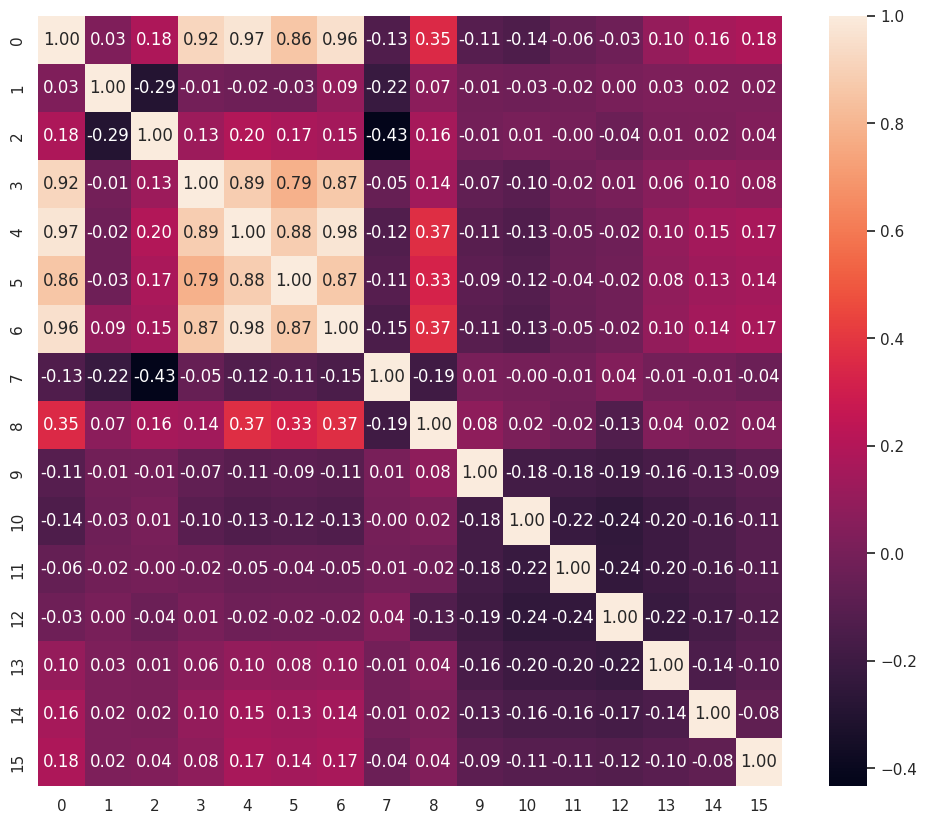

In [152]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(corr_m, annot=True, fmt='.2f')

<Axes: >

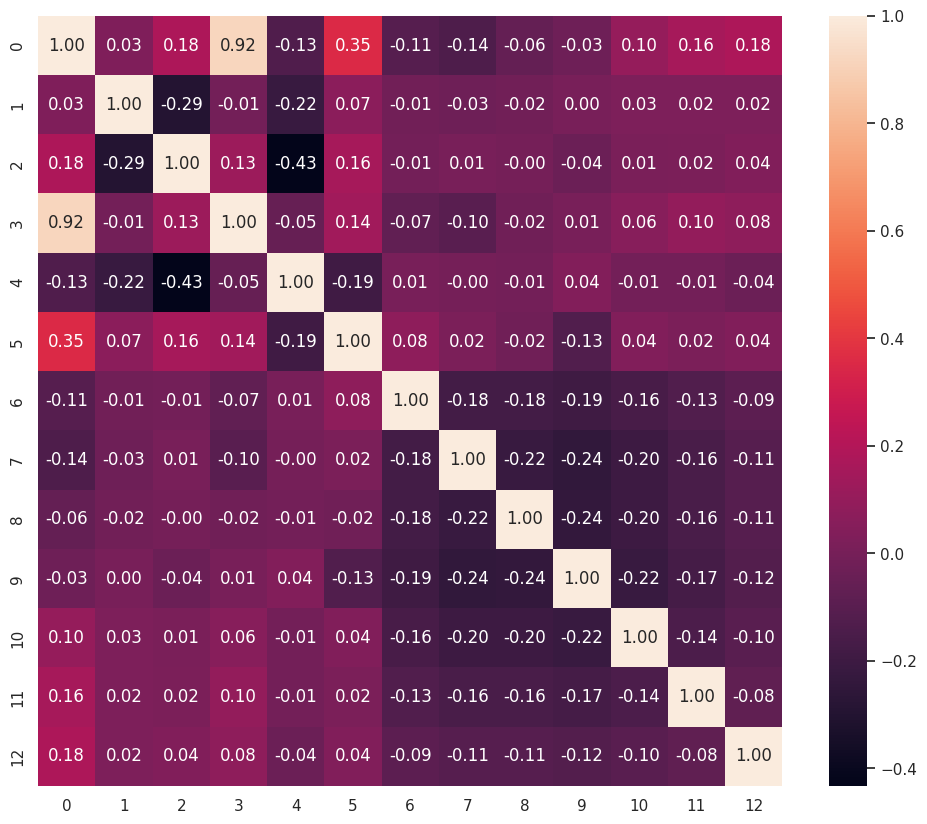

In [153]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(df_encoded.drop(['x','y','z']).corr(), annot=True, fmt='.2f')

<Axes: >

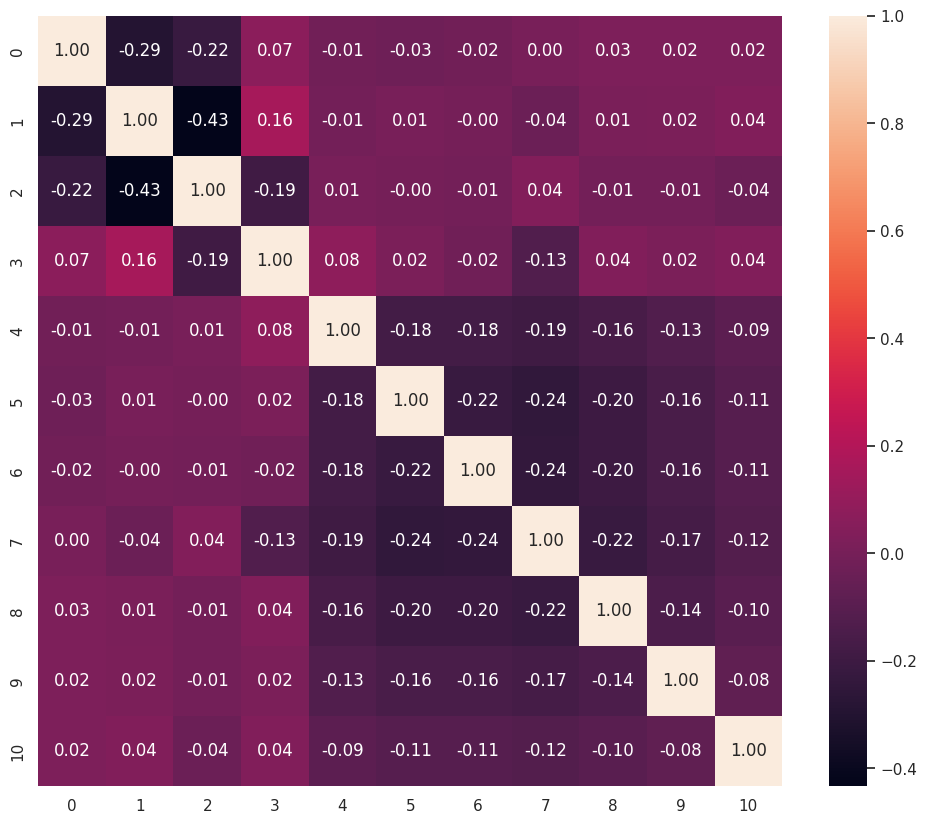

In [154]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(df_encoded.drop(['x','y','z', 'price', 'carat']).corr(), annot=True, fmt='.2f')

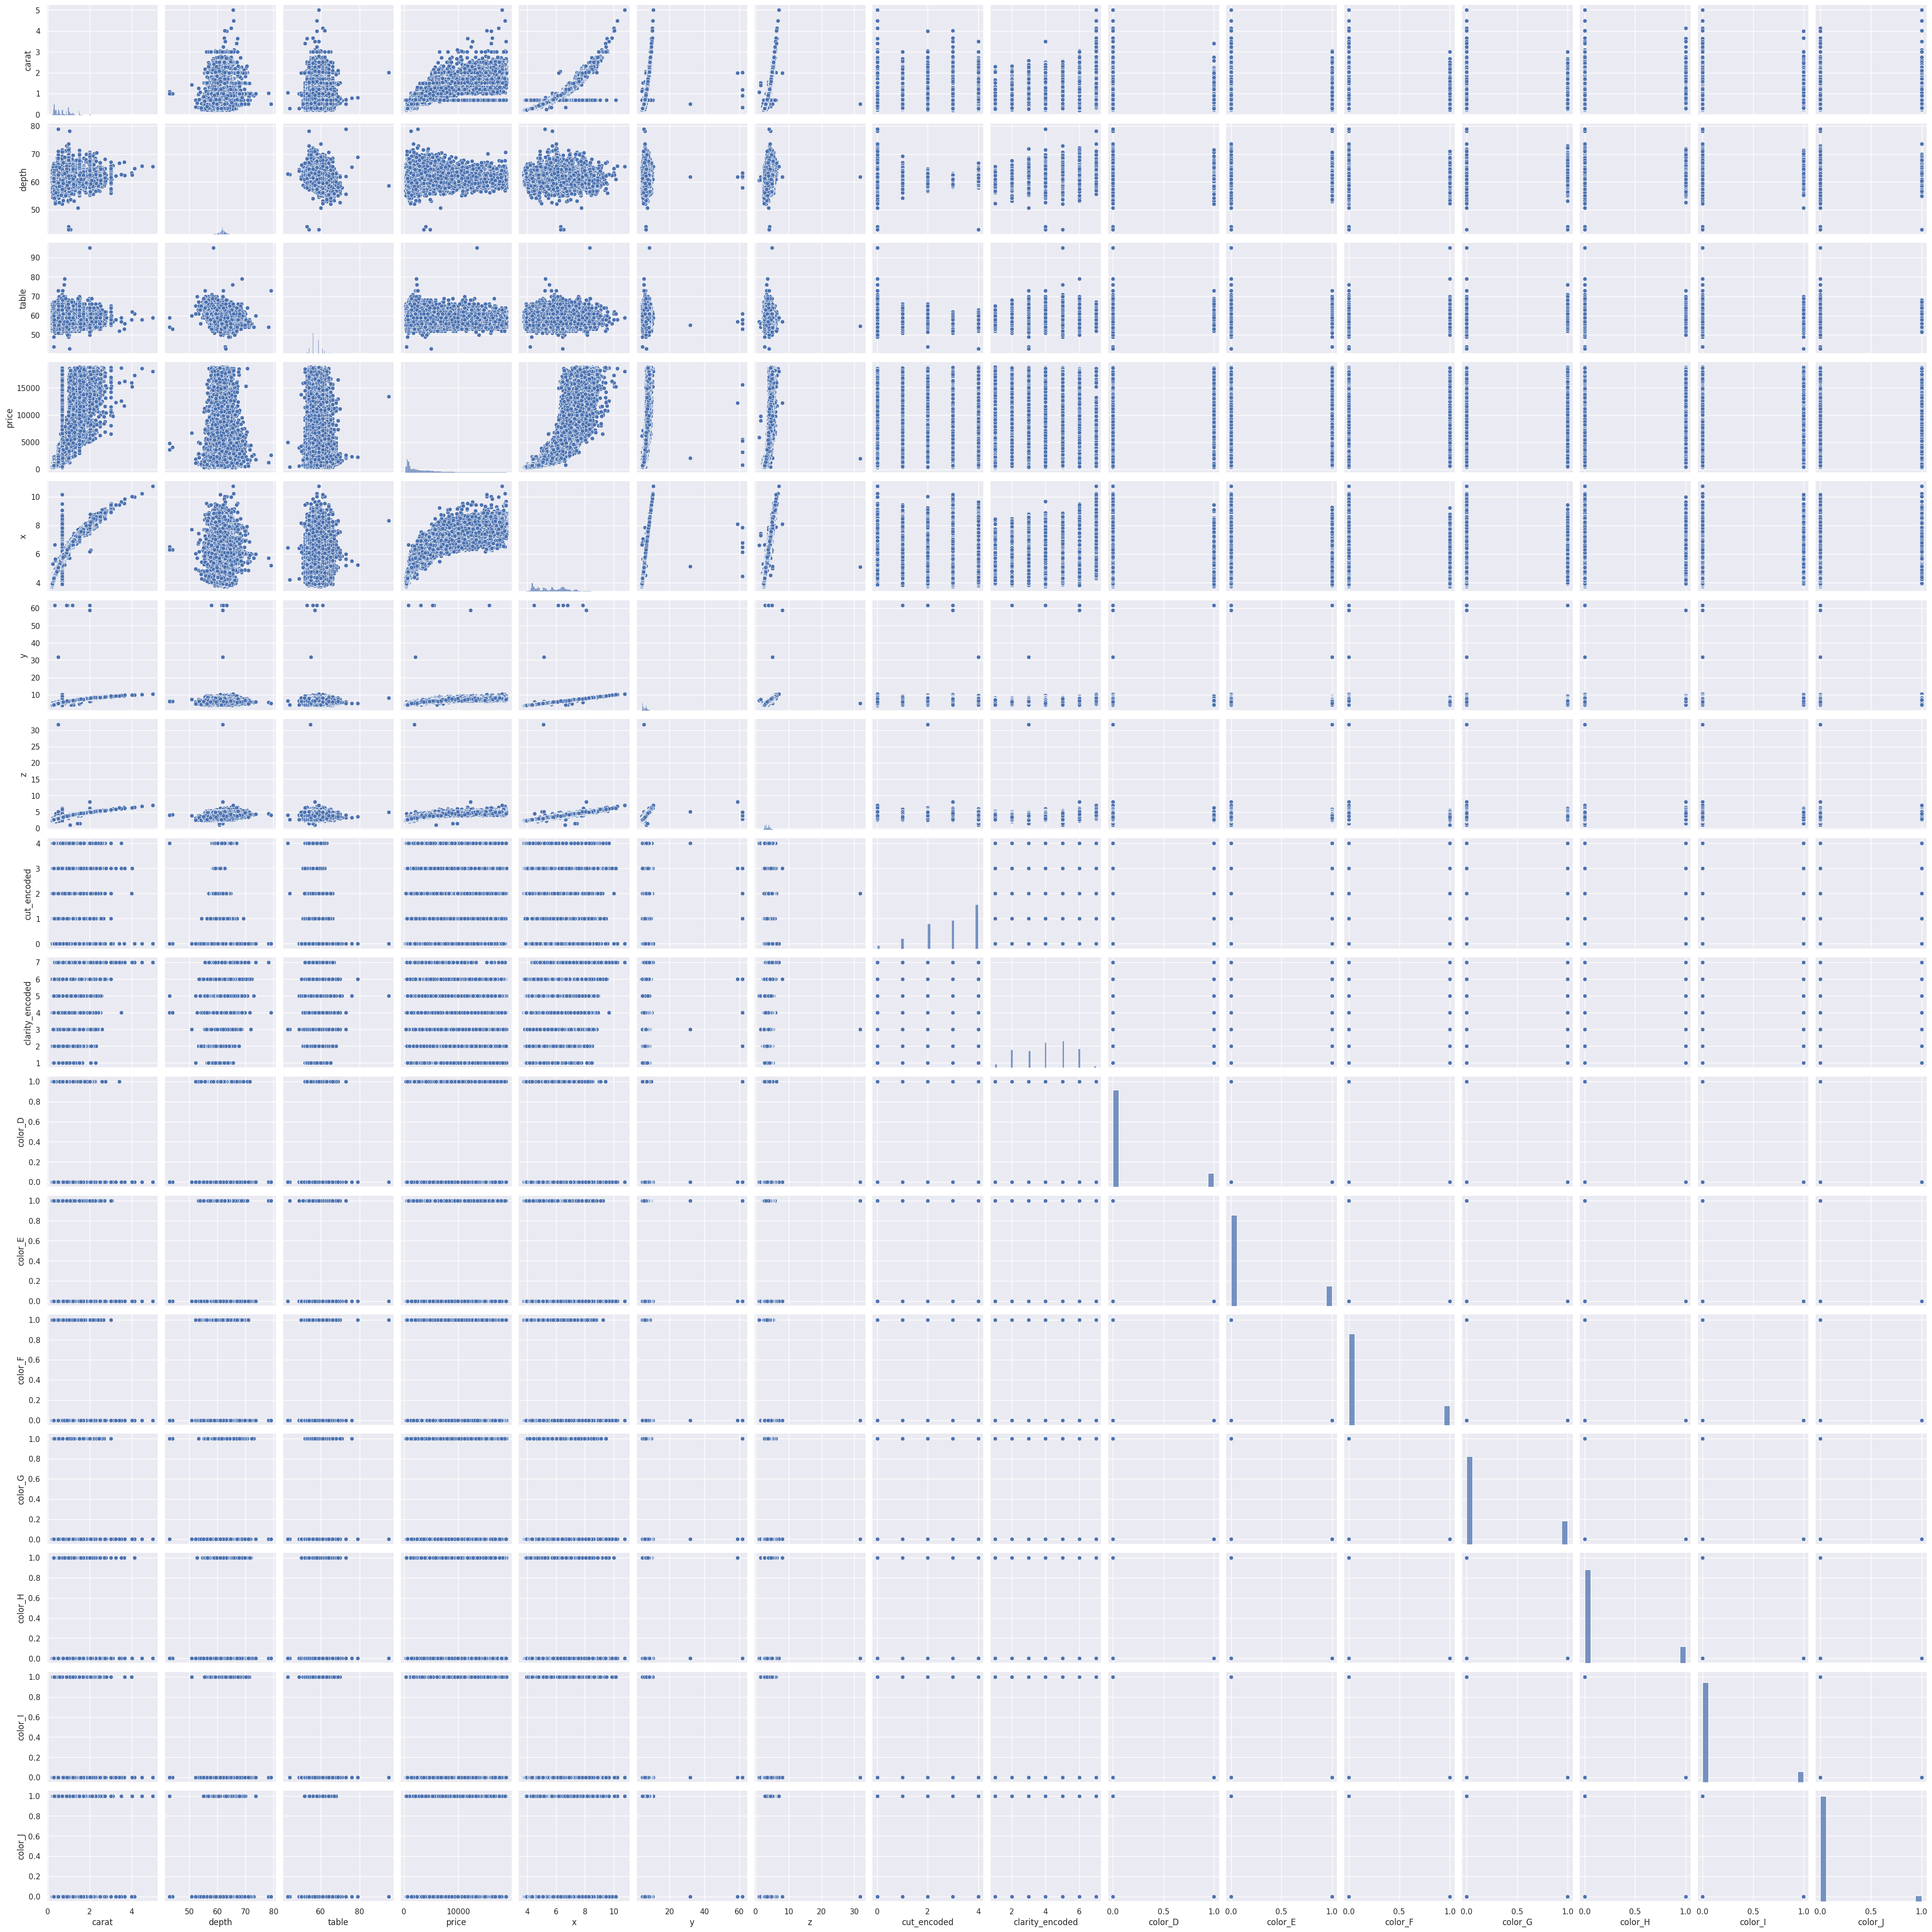

In [155]:
sns.pairplot(df_encoded.to_pandas())
plt.show()

# Важность параметров

In [156]:
x = df_encoded.drop(['price'])
y = df_encoded['price']

In [157]:
x.head(5)

carat,depth,table,x,y,z,cut_encoded,clarity_encoded,color_D,color_E,color_F,color_G,color_H,color_I,color_J
f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64
0.33,61.6,55.0,4.46,4.5,2.76,4,4,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0.7,61.2,57.0,5.68,5.73,3.49,2,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
0.38,62.5,57.0,4.64,4.61,2.89,4,7,0.0,0.0,1.0,0.0,0.0,0.0,0.0
0.7,62.2,59.0,5.68,5.64,3.52,3,4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1.51,63.2,57.0,7.18,7.32,4.58,2,4,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [158]:
y.head(5)

price
f64
873.0
2753.0
638.0
2648.0
10950.0


## RandomForest

In [159]:
from sklearn.ensemble import RandomForestRegressor

In [160]:
rf = RandomForestRegressor(n_estimators=100, random_state=43)
rf.fit(x, y)

RandomForestRegressor(random_state=43)

In [163]:
feature_importances_series = pl.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
}).sort(by='Importance', descending=True)
feature_importances_series

Feature,Importance
str,f64
"""y""",0.862062
"""clarity_encoded""",0.062362
"""x""",0.015056
"""carat""",0.01409
"""color_J""",0.010979
…,…
"""color_G""",0.00245
"""table""",0.002334
"""color_E""",0.001729


### Permutation importance

In [164]:
from sklearn.inspection import permutation_importance

res = permutation_importance(rf, x, y, n_repeats=10, n_jobs=-1, random_state=35)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [165]:
ir = res.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res.importances_mean[i]:.3f} std {res.importances_std[i]:.3f}')

y: 1.087 std 0.007
clarity_encoded: 0.167 std 0.001
x: 0.067 std 0.000
carat: 0.042 std 0.000
color_J: 0.041 std 0.001
color_I: 0.033 std 0.001
z: 0.028 std 0.000
color_H: 0.019 std 0.000
color_D: 0.013 std 0.000
color_G: 0.010 std 0.000
color_E: 0.008 std 0.000
color_F: 0.008 std 0.000
depth: 0.004 std 0.000
cut_encoded: 0.003 std 0.000
table: 0.003 std 0.000


## GradientBoosting

In [166]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=43)
gb.fit(x, y)

GradientBoostingRegressor(random_state=43)

In [168]:
feature_importances_series = pl.DataFrame({
    'Feature': x.columns,
    'Importance': gb.feature_importances_
}).sort(by='Importance', descending=True)
feature_importances_series

Feature,Importance
str,f64
"""y""",0.785894
"""z""",0.106216
"""clarity_encoded""",0.058337
"""x""",0.017096
"""carat""",0.010107
…,…
"""color_G""",0.000845
"""color_E""",0.000715
"""cut_encoded""",0.000366


### Permutation importance

In [169]:
res_gb = permutation_importance(gb, x, y, n_repeats=10, n_jobs=-1, random_state=35)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [170]:
ir = res_gb.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res_gb.importances_mean[i]:.3f} std {res_gb.importances_std[i]:.3f}')

y: 0.852 std 0.004
z: 0.171 std 0.001
clarity_encoded: 0.132 std 0.001
carat: 0.036 std 0.000
x: 0.022 std 0.000
color_J: 0.020 std 0.000
color_I: 0.010 std 0.000
color_D: 0.006 std 0.000
color_E: 0.004 std 0.000
color_H: 0.003 std 0.000
color_F: 0.003 std 0.000
cut_encoded: 0.001 std 0.000
color_G: 0.001 std 0.000
depth: 0.000 std 0.000
table: 0.000 std 0.000


## LinearRegression

In [171]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [172]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [173]:
lr = LinearRegression()
lr.fit(x_scaled, y)

LinearRegression()

In [175]:
feature_importances_series = pl.DataFrame({
    'Feature': x.columns,
    'Coeff': lr.coef_,
    'Coeff_abs': np.abs(lr.coef_)
}).sort(by='Coeff_abs', descending=True)
feature_importances_series

Feature,Coeff,Coeff_abs
str,f64,f64
"""carat""",4192.746052,4192.746052
"""clarity_encoded""",-842.994521,842.994521
"""color_J""",-361.018871,361.018871
"""color_I""",-226.104048,226.104048
"""color_D""",212.676627,212.676627
…,…,…
"""table""",-48.98309,48.98309
"""color_G""",39.416376,39.416376
"""x""",-35.350318,35.350318


### Permutation importance

In [176]:
res_lr = permutation_importance(lr, x_scaled, y, n_repeats=10, n_jobs=-1, random_state=35)

In [177]:
ir = res_lr.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res_lr.importances_mean[i]:.3f} std {res_lr.importances_std[i]:.3f}')

carat: 2.212 std 0.010
clarity_encoded: 0.089 std 0.001
color_J: 0.017 std 0.000
color_I: 0.006 std 0.000
color_D: 0.006 std 0.000
color_E: 0.003 std 0.000
cut_encoded: 0.002 std 0.000
color_H: 0.002 std 0.000
color_F: 0.002 std 0.000
depth: 0.001 std 0.000
table: 0.000 std 0.000
color_G: 0.000 std 0.000
x: 0.000 std 0.000
z: 0.000 std 0.000
y: 0.000 std 0.000


# Обучение моделей

In [178]:
from sklearn.model_selection import train_test_split

In [179]:
df_two_features = df_encoded[['price', 'y', 'clarity_encoded']]
df_three_features = df_encoded[['price', 'cut_encoded', 'carat', 'clarity_encoded']]

## RandomForest

In [198]:
def get_data(cur_df):
  x = cur_df.drop('price').to_numpy()
  y = cur_df['price'].to_numpy()

  y_bins = np.quantile(y, np.linspace(0, 1, 11))
  y_binned = np.digitize(y, y_bins[1:-1])

  x_train, x_test, y_train, y_test = train_test_split(
      x, y, test_size=0.3, random_state=42, stratify=y_binned
  )

  return x_train, x_test, y_train, y_test

### Features 'y' and 'clarity'

In [199]:
x_train, x_test, y_train, y_test = get_data(df_two_features)

In [200]:
rf = RandomForestRegressor(n_estimators=100, random_state=43)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=43)

In [201]:
from sklearn.metrics import mean_absolute_percentage_error

y_pred = rf.predict(x_test)
print('RandomForest mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

RandomForest mape = 0.1476110137009329


### Features 'cut' and 'carat' and 'clarity'

In [188]:
x_train, x_test, y_train, y_test = get_data(df_three_features)

In [189]:
rf = RandomForestRegressor(n_estimators=100, random_state=43)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=43)

In [190]:
y_pred = rf.predict(x_test)
print('RandomForest mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

RandomForest mape = 0.14955013237014275


## Linear Regression

In [196]:
def get_data_scaled(cur_df):
  x = cur_df.drop('price').to_numpy()
  y = cur_df['price'].to_numpy()

  scaler = StandardScaler()
  x_scaled = scaler.fit_transform(x)

  y_bins = np.quantile(y, np.linspace(0, 1, 11))
  y_binned = np.digitize(y, y_bins[1:-1])

  x_train, x_test, y_train, y_test = train_test_split(
      x_scaled, y, test_size=0.3, random_state=42, stratify=y_binned
  )

  return x_train, x_test, y_train, y_test

### Features 'y' and 'clarity'

In [197]:
x_train, x_test, y_train, y_test = get_data_scaled(df_two_features)

In [202]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [203]:
y_pred = lr.predict(x_test)
print('Linear regression mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

Linear regression mape = 0.4467168014989079


### Features 'cut' and 'carat' and 'clarity'

In [204]:
x_train, x_test, y_train, y_test = get_data_scaled(df_three_features)

In [205]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [206]:
y_pred = lr.predict(x_test)
print('Linear regression mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

Linear regression mape = 0.44418637323802046


# Итог
Наилучшим образом себя показала линейная регрессия на параметрах y + clarity